# PRÁCTICA BACKTESTING AVANZADO

##### Realizado por Mateo Santos

In [1]:
# Importamos las librerías
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pyarrow
import pyarrow.parquet as pq
import time

# Fijamos la semilla
np.random.seed(42)

In [2]:
# Definición de variables globales
capital = 250000
#START_DATE = '2015-01-01'
START_DATE = '2014-01-01'
END_DATE = '2026-01-31'
NUM_ACTIVOS = 20
capital_por_activo = capital/NUM_ACTIVOS

## Notebook 1: Carga de Datos

Leemos los datos de las cotizaciones de precios del universo de activos. Podemos apreciar que **aparecen en formato largo**. Es decir, **las claves primarias de cada fila son la fecha y el activo (symbol)**. Habrá que modificar la estructura de los datos y hacer una serie de filtrados para tener el dataset final con el que trabajar.

Se realiza un procesamiento de los datos al eliminar los tickers duplicados. Nos quedamos con los tickers que tienen un mayor volumen, que implica que son activos más líquidos y, por tanto, más fáciles de negociar.

In [3]:
# 1. Carga de datos
precios_activos = pq.read_table('sp500_history.parquet').to_pandas()

# 2. Calcular el volumen total por Ticker para cada Empresa. Nos dice qué ticker es el "dominante" históricamente
volumen_por_ticker = precios_activos.groupby(['security_name', 'symbol'])['volume'].sum().reset_index()

# 3. Para cada empresa, encontrar el registro con el volumen máximo
# Ordenamos por volumen descendente y nos quedamos con el primero por cada nombre de empresa
tickers_ganadores = volumen_por_ticker.sort_values('volume', ascending=False) \
                                      .drop_duplicates(subset=['security_name'], keep='first')

# 4. Filtrar el DataFrame original usando solo los pares (Empresa, Ticker) con mayor volumen
# Hacemos un 'merge' tipo inner para descartar los tickers secundarios
precios_activos_consistentes = pd.merge(precios_activos, 
    tickers_ganadores[['security_name', 'symbol']], on=['security_name', 'symbol'], how='inner')

# 5. Finalmente, eliminamos duplicados por fecha por si acaso (limpieza estándar)
precios_activos = precios_activos_consistentes.drop_duplicates(subset=['security_name', 'date'])

precios_activos.head()

,date,symbol,assetid,security_name,sector,industry,subsector,in_sp500,open,high,low,close,volume,unadjusted_close
0,1999-11-18,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,27.188307,29.877260,23.901808,25.545057,74862288.0,42.7500
1,1999-11-19,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,25.657097,25.694445,23.789768,24.349968,18236110.0,40.7500
2,1999-11-22,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,24.686087,26.067909,23.939156,26.067909,7874048.5,43.6250
3,1999-11-23,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,25.395672,26.067909,24.051195,24.051195,7153099.0,40.2500
4,1999-11-24,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,23.976501,25.059551,23.901808,24.536699,5797720.5,41.0625


Leemos los datos de las **cotizaciones diarias del S&P 500** a través de lal librería yfinance. Nos quedamos con los precios de apertura y cierre.

In [4]:
# Leer el archivo de precios del sp500. Nos quedamos con los precios de cierre y de apertura
precios_sp500 = yf.download('^GSPC', start=START_DATE, end=END_DATE)[['Close', 'Open']]
precios_sp500.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,Open
Ticker,^GSPC,^GSPC
Date,,
2014-01-02,1831.979980,1845.859985
2014-01-03,1831.369995,1833.209961
2014-01-06,1826.770020,1832.310059
2014-01-07,1837.880005,1828.709961
2014-01-08,1837.489990,1837.900024


## Notebook 2: EDA (Exploratory Data Analysis) y preparación de los datos

### 2.1. Análisis exploratorio de datos

Para el primer análisis exploratorio de los datos, usaremos los que están en formato largo. Lo que nos interesa aquí es ver la distibución de los activos en función de las variables categóricas existentes:

- **sector**: Indica el sector al que pertenece la empresa.
- **industry**: Indica la industria al que pertenece la empresa.
- **in_sp500**: Indica si la empresa pertenece al S&P500

In [5]:
# 1. Agrupamos incluyendo sector e industry
pertenencia = precios_activos.groupby('security_name').agg({
    'in_sp500': ['sum', 'count'],
    'sector': 'first',      # Ajusta el nombre si en tu dataset es 'sector'
    'industry': 'first' # Ajusta el nombre si es 'industry'
}).reset_index()

# 2. Aplanar los niveles de las columnas (el groupby con agg crea un MultiIndex)
pertenencia.columns = ['security_name', 'sum_in', 'total_days', 'sector', 'industry']

# 3. Definimos las 3 categorías con los nuevos nombres de columna
def clasificar_persistencia(row):
    if row['sum_in'] == row['total_days']:
        return 'Siempre'
    elif row['sum_in'] == 0:
        return 'Nunca'
    else:
        return 'Intermitente'

pertenencia['categoria_sp500'] = pertenencia.apply(clasificar_persistencia, axis=1)

El primer gráfico muestra la proporción de activos que se han mantenido en el S&P 500 durante todo el periodo en el que tenemos datos (desde 1990) comparado con las empresas que han estado a veces y con las que no han estado nunca en el índice.

Como conclusión:
- Hay **298 empresas** que se han mantenido **desde 1990** hasta la actualidad en el **S&P 500**.
- **El resto de empresas** han compaginado periodos en los que se incluían en el S&P 500 con periodos en el que no estaban en él.
- Por extensión, no hay ninguna empresa que no haya estado nunca en el S&P 500.

C:\Users\mateo\AppData\Local\Temp\ipykernel_2064\3113352112.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


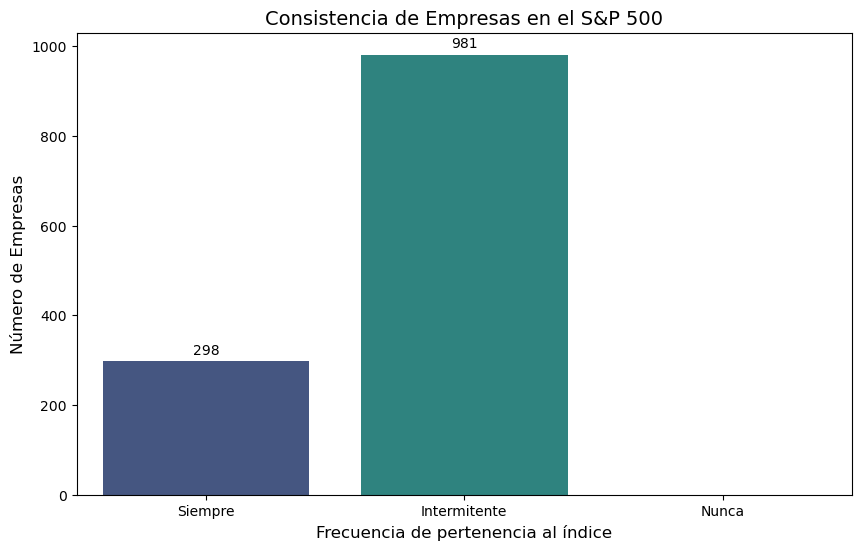

In [6]:
plt.figure(figsize=(10, 6))

# Definimos el orden para que el gráfico sea intuitivo
orden = ['Siempre', 'Intermitente', 'Nunca']

ax = sns.countplot(
    data=pertenencia, 
    x='categoria_sp500', 
    order=orden,
    palette='viridis' # Una paleta distinta para diferenciar del gráfico anterior
)

# Añadimos las etiquetas sobre las barras
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Consistencia de Empresas en el S&P 500', fontsize=14)
# Ajustamos etiquetas para que se entienda el criterio
plt.xlabel('Frecuencia de pertenencia al índice', fontsize=12)
plt.ylabel('Número de Empresas', fontsize=12)

plt.show()

El segundo gráfico muestra el **conteo de empresas por sector**. 

- **Los tres sectores más representados son**:
    - Financiero
    - Industrial
    - Consumo discrecional

- **Los tres sectores menos representados son**:
    - Consumer staples (Bienes de consumo básico)
    - Utilities (Servicios públicos)
    - Real estate (Inmobiliario)

Además, se pueden obtener conclusiones en función de la **presencia de las empresas de cada sector en el S&P 500**. Dicho de otro modo, permite visualizar el **ratio de supervivencia** promedio en cada sector. Destaca:

- **Los tres sectores con un mayor ratio de supervivencia en el S&P 500 son**:
    - Utilities (Servicios públicos)
    - Consumer staples (Consumo básico)
    - Materiales

- **Los tres sectores con un menor ratio de supervivencia en el S&P 500 son**:
    - Consumer discretionary (Consumo discrecional)
    - Information technology (IT)
    - Real estate (Inmobiliario)

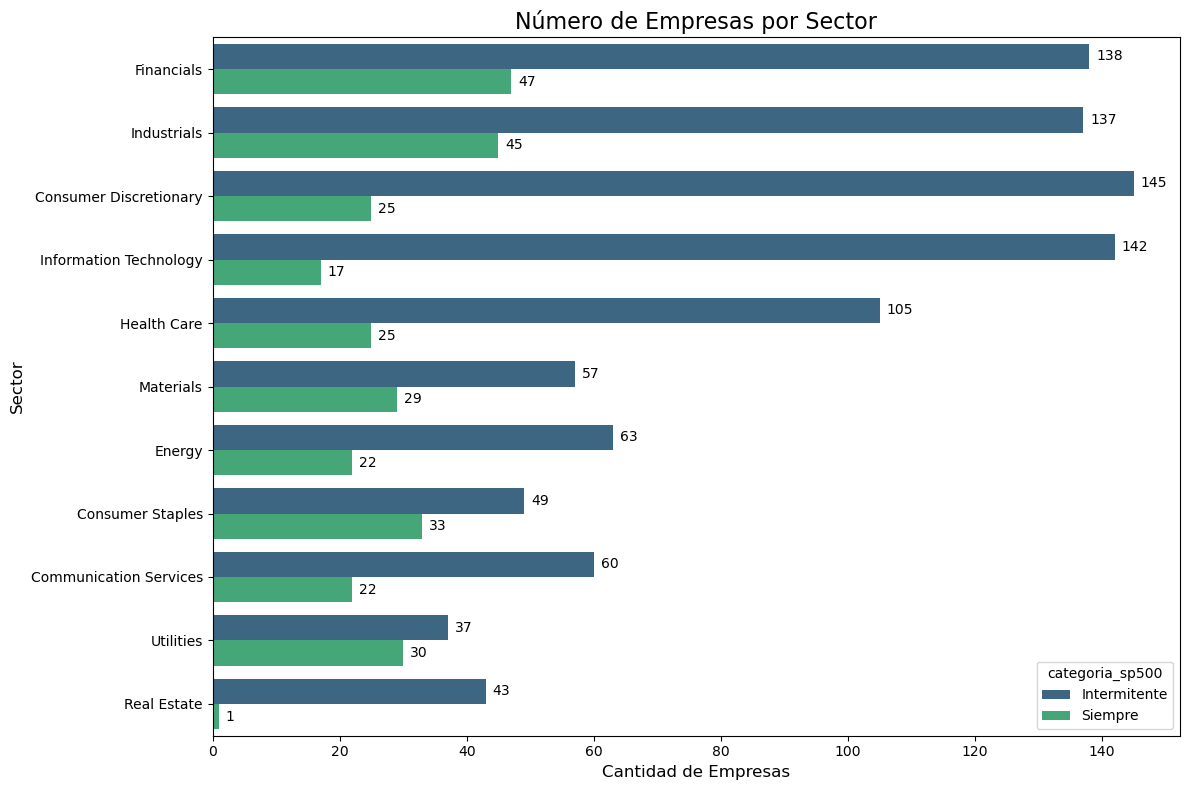

In [7]:
plt.figure(figsize=(12, 8))

# Calculamos el orden
order_sectores = pertenencia['sector'].value_counts().index

# Dibujamos
ax = sns.countplot(
    data=pertenencia, 
    y='sector', 
    palette='viridis',
    hue = 'categoria_sp500',
    order=order_sectores
)

# Añadimos las etiquetas de conteo
for container in ax.containers:
    ax.bar_label(container, padding=5)

plt.title('Número de Empresas por Sector', fontsize=16)
plt.xlabel('Cantidad de Empresas', fontsize=12)
plt.ylabel('Sector', fontsize=12)

plt.tight_layout()
plt.show()

El tercer gráfico muestra el **conteo de empresas por industria**. 

- **Las tres industrias más representadas son**:
    - Energía
    - Banca
    - Seguros

- **Las tres industrias menos representadas son**:
    - Servicios públicos de agua
    - Infraestrucutra de transporte
    - Hotel & Resort RETI (Hoteles)

C:\Users\mateo\AppData\Local\Temp\ipykernel_2064\2552397513.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


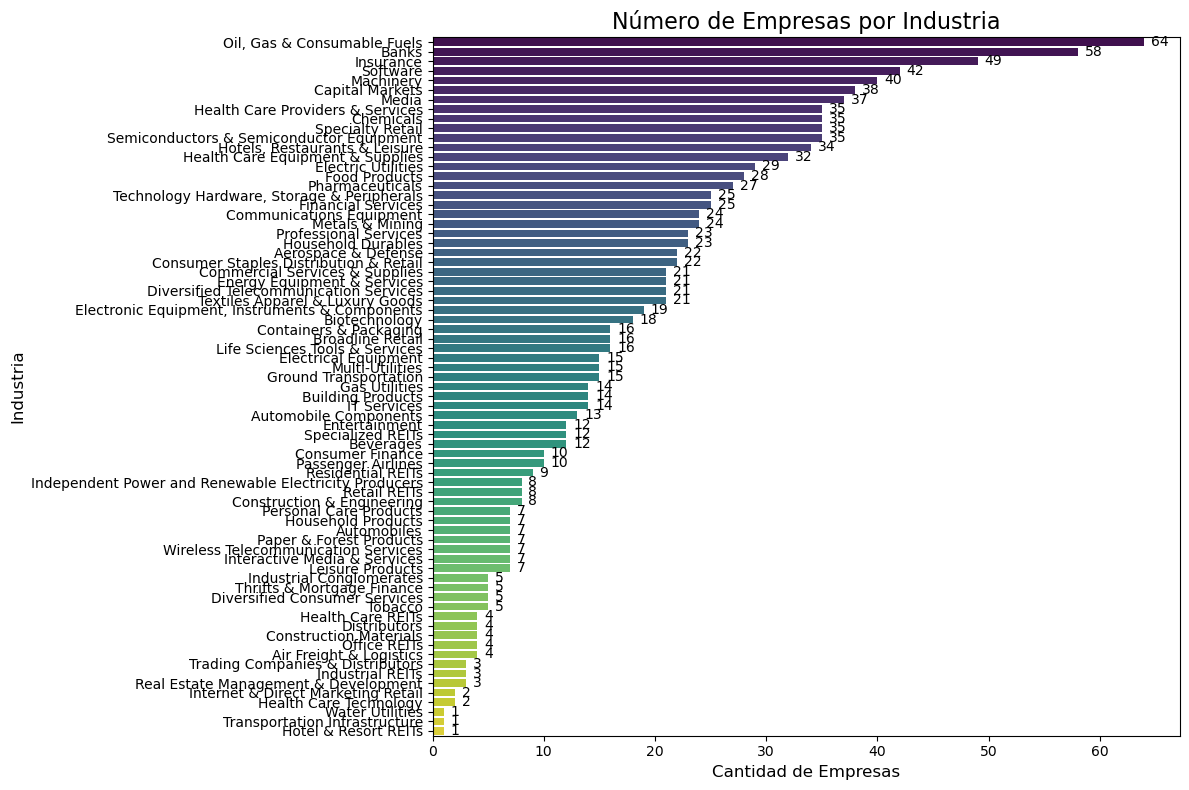

In [8]:
plt.figure(figsize=(12, 8))

# Calculamos el orden
order_sectores = pertenencia['industry'].value_counts().index

# Dibujamos
ax = sns.countplot(
    data=pertenencia, 
    y='industry', 
    palette='viridis', 
    order=order_sectores
)

# Añadimos las etiquetas de conteo
for container in ax.containers:
    ax.bar_label(container, padding=5)

plt.title('Número de Empresas por Industria', fontsize=16)
plt.xlabel('Cantidad de Empresas', fontsize=12)
plt.ylabel('Industria', fontsize=12)

plt.tight_layout()
plt.show()

### 2.2. Preparación de datos

Gracias a la función **`obtener_matrices_control`** filtramos todos los precios de todos los activos que tienen una **vigencia de al menos 13 meses en el S&P 500**. El funcionamiento es el siguiente:

En primer lugar, vemos para cada uno de los días de cotización de cada activo, los días que se encuentre en el S&P 500. Todos los días que esté se le asigna un valor `True` y, en caso contrario, se le asigna el valor `False`.

Por otro lado, para cada mes de cada activo, se comprueba si en los anteriores 13 meses ha estado de forma ininterrumpida en el S&P 500. En caso de que sea así, esa celda tendra un valor `True` y en caso contrario `False`.

Las matrices booleanas permiten operar con las matrices numéricas al tratar los valores `True` como unos y los `False` como ceros.

In [9]:
# Función para generar mascaras de acuerdo con las condiciones de pertenencia y salida del S&P 500 y del mercado
def obtener_matrices_control(df):
    df['date'] = pd.to_datetime(df['date'])
    
    # Esta es la presencia REAL día a día (la que usaremos para vender si salen del SP500)
    presencia_diaria = df.pivot(index='date', columns='symbol', values='in_sp500').fillna(False)
    
    # Lógica de los 13 meses (la que usas para elegir qué comprar)
    presencia_mensual = presencia_diaria.resample('BME').max()
    cumple_13_meses = presencia_mensual.rolling(window=13).sum() == 13
    activos_aptos = cumple_13_meses.reindex(presencia_diaria.index, method='ffill').fillna(False)
    
    return activos_aptos, presencia_diaria

activos_aptos, matriz_sp500 = obtener_matrices_control(precios_activos)

C:\Users\mateo\AppData\Local\Temp\ipykernel_2064\2708021416.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  activos_aptos = cumple_13_meses.reindex(presencia_diaria.index, method='ffill').fillna(False)


A continuación, fijamos como índice a la variable `date`. Finalmente filtramos por las variables de interés:

- **symbol**: Ticker de empresa
- **security_name**: Nombre de empresa
- **sector**: Sector de pertenencia de cada empresa
- **industry**: Industria de pertenencia de cada empresa
- **subsector**: Subsector de pertenencia de cada empresa
- **in_sp500**: Variable categórica que indica la presencia diaria en el S&P 500
- **open**: Precios de apertura
- **close**: Precios de cierre

In [10]:
# Hacemos que la fecha pase a ser índice y borramos la columna fecha
precios_activos['date'] = pd.to_datetime(precios_activos['date'])
precios_activos = precios_activos.set_index('date').sort_index()

# Seleccionamos la fecha correcta y las variables de interés.
# Descartamos las variables (assetid, high, low, volume y unadjusted_close)
lista_variables = ['symbol', 'security_name', 'sector', 'industry', 'subsector', 'in_sp500', 'open', 'close']
precios_activos = precios_activos[lista_variables]

# Filtramos los datos a partir del 2015-01-01
precios = precios_activos.loc[START_DATE:].copy()

La función **`large_to_wide_df`** es la que nos permite pasar los datos de **formato largo a ancho** haciendo uso de la función **`pivot`**. 

Esta función agrupa por `symbol` ya que el Ticker identifica univocamente a cada activo. De este modo, los Tickers pasan a ser las columnas de este nuevo dataframe. Los valores que tomará cada columna serán los precios de cierre en un caso (`precios_close`) y los de apertura en el otro (`precios_open`).

Por último, se filtra por las posiciones válidas `where(activos_aptos)` que habíamos detectado al principio siguiendo la condición de **permanencia de al menos 13 meses en el S&P 500**.

In [11]:
# Función para pasar los datos de formato largo a ancho
def large_to_wide_df(df_large, columns = 'symbol', values = 'close'):
    # Agrupamos los datos en función del ticker del activo (symbol) y seleccionamos los valores values.
    df_wide = df_large.pivot(columns = columns, values = values)
    return df_wide

In [12]:
# Obtenemos los datos en formato ancho para los precios close y open de cada activo
# Filtramos por las fechas en las que los activos han estado al menos 13 meses seguidos en el SP500 -> .where(activos_aptos)
precios_close = large_to_wide_df(precios, columns = 'symbol', values = 'close').where(activos_aptos)
precios_open = large_to_wide_df(precios, columns = 'symbol', values = 'open').where(activos_aptos)

Una vez, ya tenemos los datos en el formato habitual de yfinance (ordenado por filas y columnas **(fechas x activos)**), podemos pasar a calcular los retornos logarítmicos diarios gracias a la función **`get_returns`**.

In [13]:
# Función para obtener los retornos logarítmicos diarios a partir de los precios diarios de cada activo
def get_returns(precios_close):
    returns_close = np.log(precios_close).diff()
    return returns_close.iloc[1:]

In [14]:
# Obtenemos los retornos logarítmicos de los activos diarios sobre los precios de cierre y los de apertura
returns_close = get_returns(precios_close)
returns_open = get_returns(precios_open)

# Tambien para el sp500
returns_sp500 = get_returns(precios_sp500['Close'])

### 2.3. Análisis exploratorio sobre retornos

Tras calcular los retornos se muestran tres gráficos que podrían ser interesantes para estudiar. Como en este caso, el universo de activos seleccionables es demasiado grande, no se pueden obtener conclusiones. En otros casos, sí que sería de utilidad.

**Los tres gráficos siguientes muestran**:
- La evolución de los retornos reales de los primeros 20 activos del dataset.
- La matriz de correlaciones de los activos
- El ratio rentabilidad versus riesgo de los activos

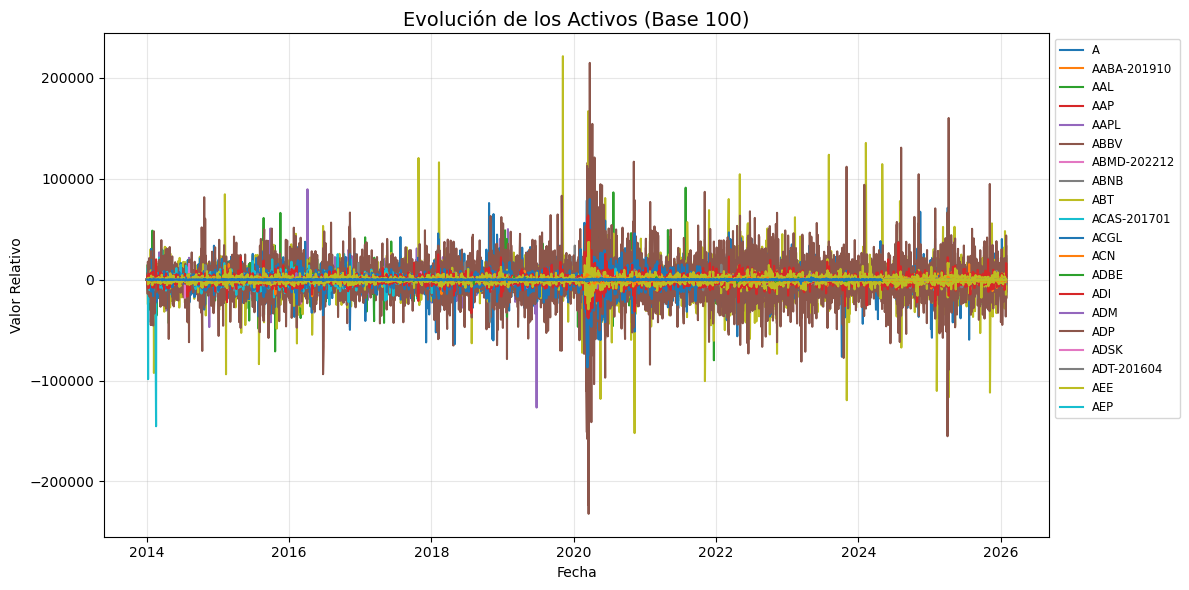

In [15]:
# Normalizamos: (Precio final/ Primer Precio) * 100 -> Wealth index
returns_close_norm = (returns_close / returns_close.iloc[0]) * 100

plt.figure(figsize=(12, 6))
plt.plot(returns_close_norm)

# Añadimos leyenda y etiquetas
plt.legend(returns_close_norm.columns[:20], loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
plt.title('Evolución de los Activos (Base 100)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Valor Relativo')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

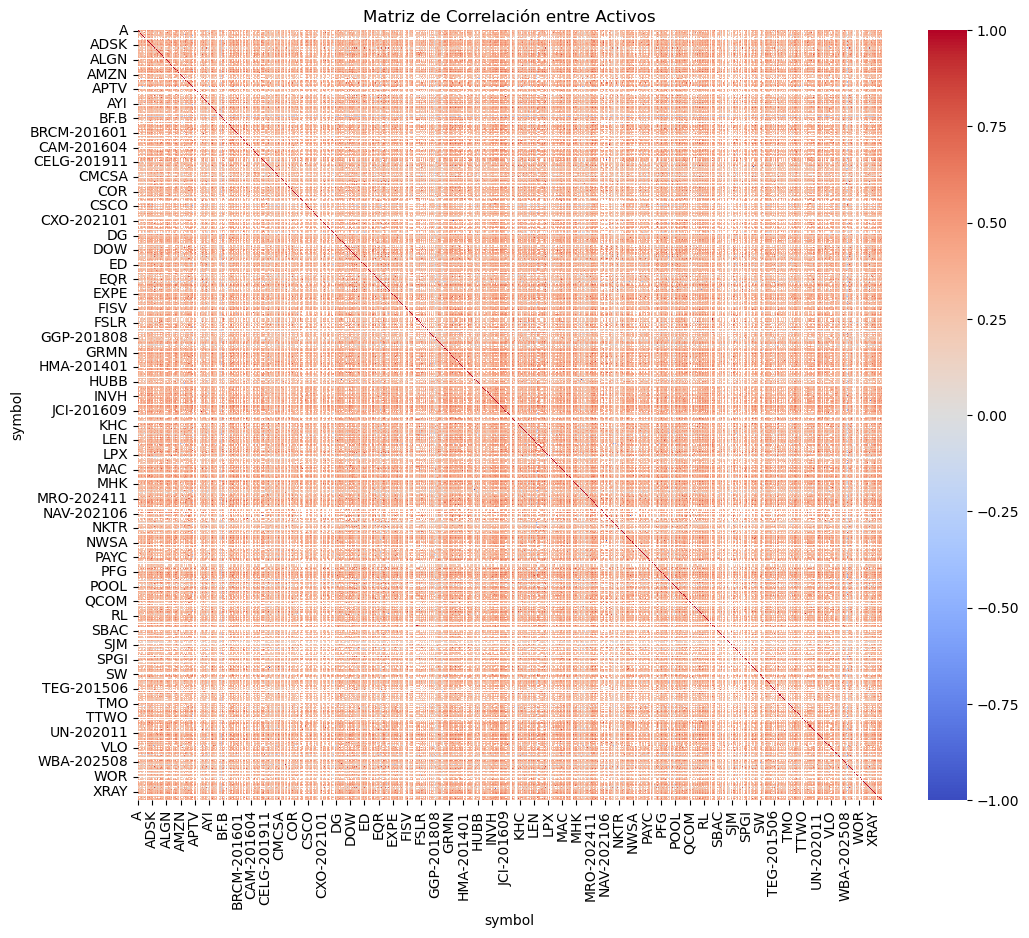

In [16]:
# Calculamos la matriz de correlación de los retornos
corr = returns_close.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación entre Activos')
plt.show()

C:\Users\mateo\AppData\Local\Temp\ipykernel_2064\2011368743.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(activo, (volatilidades[i], rentabilidades[i]), xytext=(5, 5), textcoords='offset points', fontsize=9)


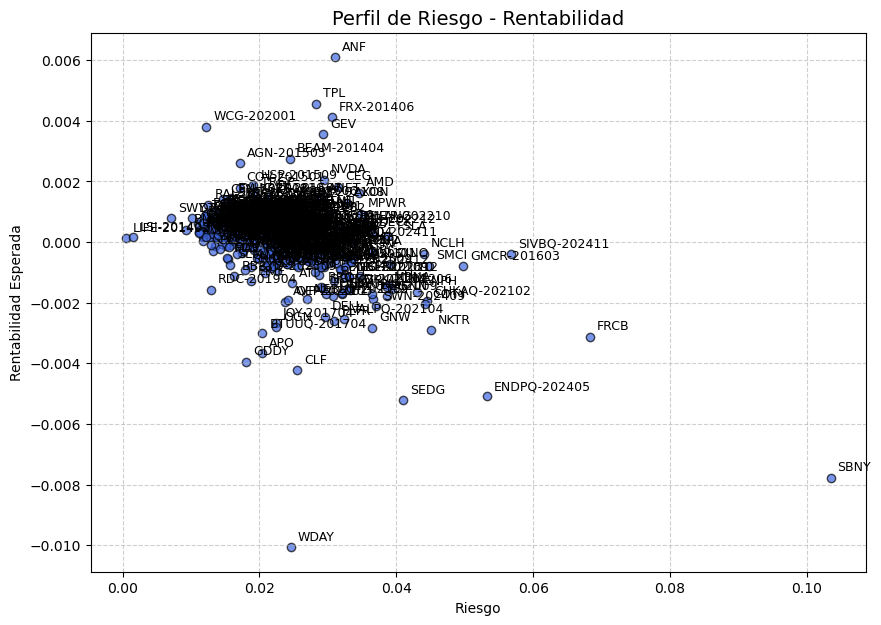

In [17]:
# Obtenemos los vectores de medias y volatilidades. Cada posición corresponde a un activo 
rentabilidades = returns_close.mean()
volatilidades = returns_close.std()

# Creamos el gráfico
plt.figure(figsize=(10, 7))
plt.scatter(volatilidades, rentabilidades, alpha=0.7, c='royalblue', edgecolors='k')

# Añadimos las etiquetas de los activos
for i, activo in enumerate(volatilidades.index):
    plt.annotate(activo, (volatilidades[i], rentabilidades[i]), xytext=(5, 5), textcoords='offset points', fontsize=9)

# Personalización
plt.title('Perfil de Riesgo - Rentabilidad', fontsize=14)
plt.xlabel('Riesgo')
plt.ylabel('Rentabilidad Esperada')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## Notebook 3: Implementación de la estrategia

### 3.1. Paso A: Retorno Acumulado con "Lag" de 1 Mes

La función **`get_momentum_raw`** calcula el momentum acumulado durante los últimos **$r$** meses a partir de los retornos con un lag de un mes.

Gracias a las propiedades aditivas de **retornos logarítmicos**, el valor del momentum se calcula como la **suma de los retornos desde el mes r-13 hasta el mes r-1**. Para el cálculo del momentum no se tienen en cuenta los retornos del mes actual.

In [18]:
# Función para calcular el momentum durante r meses sin contar el actual. (Desde t-1 hasta t-r-1)
def get_momentum_raw(returns, r):
    # Obtenemos la suma de los retornos de cada mes. La suma de los retornos logarítmicos es la rentabilidad acumulada mensual
    df = returns.resample('BME').sum()
    # Realizamos la agregación en función del número de periodos. 
    # Como cada mes tiene la rentabilidad acumulada. El momentum se calcula como la suma de estas rentabilidades logarítmicas
    # acumuladas
    df = df.rolling(window=r).sum()
    # Tenemos en cuenta los meses desde t-1 hasta t-r-1
    return df.shift(1).iloc[r:]

In [19]:
# Obtenemos los momentum de 6 meses y 12 meses para cada activo y mes
r6 = get_momentum_raw(returns_close, 6)
r12 = get_momentum_raw(returns_close, 12)

### 3.2. Paso B: Normalización por Factor (Z-Score)

La función **`get_mean_std_period`** obtiene para cada fecha la media y desviación típica de los momentum de todos los activos. Es necesario para normalizar los momentum y que sean comparables.

In [20]:
# Función para obtener la media y desviación típica de cada mes del momentum
def get_mean_std_period(r):
    r_mean = r.mean(axis = 1).values.reshape(-1,1)
    r_std = r.std(axis = 1).values.reshape(-1,1)
    return r_mean, r_std

In [21]:
# Calculamos la media y desviación del momentum para cada periodo
r6_mean, r6_std = get_mean_std_period(r6)
r12_mean, r12_std = get_mean_std_period(r12)

La función **`get_Z_values`** obtiene los valores Z de cada uno de los momentum (de 6 meses y de 12 meses). Los valores Z corresponden a la **normalización de los momentum** para que sean comparables.

Cada valor de la matriz de momentum se normaliza en función de la media y la desviación de los momentum de cada fecha tal que:
$Z = \frac{r - \mu_{r}}{\sigma_{r}}$.

Gracias a esta normalización, ahora sí que podemos comparar los momentum.

In [22]:
# Función para estandarizar los momentum
# Para cada momentum le restamos su propia media y dividimos por su desviación típica, respetando los índices
def get_Z_values(r, mu, sigma):
    return (r - mu)/sigma

In [23]:
# Seleccionamos a partir de la sexta fila para que coincidan los índices
z6 = get_Z_values(r6, r6_mean, r6_std).iloc[6:]
z12 = get_Z_values(r12, r12_mean, r12_std)

Filtramos por el último día bursátil y hábil de cada mes. Es clave porque esas fechas constituyen las de rebalanceo almacenadas en **`fechas_reales`**.

In [24]:
# Fijamos los índices que usaremos para identificar cada periodo (último día hábil de cada mes)
# Filtramos por los precios del periodo de estudio (a partir de enero de 2015)
# Seleccionamos solo los precios del día del rebalanceo para poder hacer las compras y ventas de activos
indices_rebalanceo = z12.index

# Obtenemos las posiciones de los índices de rebalanceo en el dataset de precios
# 'pad' asegura que si la fecha no existe, busque la última fecha real anterior
indices_validos_pos = precios_close.index.get_indexer(indices_rebalanceo, method='pad')

# Extraemos las fechas REALES que existen en el mercado
fechas_reales = precios_close.index[indices_validos_pos]

### 3.3. Paso C: Puntuación Compuesta y Selección

La función **`get_Z`** calcula la media simple de ambos Z-Score normalizados tal que $Z = \frac{Z_6 + Z_{12}}{2}$.

In [25]:
# El score final se obtiene como la media de los momentum 6 y 12 estandarizados
def get_Z(z_x, z_y):
    return (z_x + z_y)/2

In [26]:
# Obtenemos los Z-Scores finales que nos servirán para identificar los activos en los que hay que invertir
z = get_Z(z6, z12)
z.index = fechas_reales

Finalmente, gracias a la función **`select_assets`** seleccionamos para cada fecha invertir en los activos válidos que tengan un mayor valor Z.

Es clave la función `rank` que permite **seleccionar los activos con mayor valor Z-Score en cada fecha** y filtrar por la variable **`activos_aptos`**, que es la matriz booleana que determina en que periodos se puede invertir en cada activo.

Es clave para cada activo, que no se pueda volver a seleccionar una vez ha dejado de cotizar.

In [27]:
# Generamos una matriz booleana para cada periodo en el que asigna el valor True a los 20 activos con mayor Z-score
# Los valores booleanos True pueden actuar como valor 1. Por lo que ya tenemos la matriz binaria de pesos
def select_assets(z, n_activos = 20):
    return z.rank(axis=1, ascending=False) <= n_activos

In [28]:
# 1. Calculamos el último día de cotización
ultimo_dia_cotizacion = precios_close.notna()[::-1].idxmax()

# 2. Creamos la máscara de disponibilidad
disponibilidad_real = activos_aptos.copy()

# 3. Iteramos solo sobre activos que existan en ambos objetos
activos_comunes = disponibilidad_real.columns.intersection(ultimo_dia_cotizacion.index)

for activo in activos_comunes:
    # Aplicamos la lógica de fecha límite
    fecha_limite = ultimo_dia_cotizacion[activo]
    disponibilidad_real[activo] = disponibilidad_real[activo] & (disponibilidad_real.index < fecha_limite)

# 4. (Opcional) Si hay activos en disponibilidad_real que NO estaban en precios_close, 
# por seguridad los ponemos a False ya que no tenemos datos de su delisting
activos_sin_datos = disponibilidad_real.columns.difference(ultimo_dia_cotizacion.index)
if not activos_sin_datos.empty:
    disponibilidad_real[activos_sin_datos] = False
    print(f"Advertencia: {len(activos_sin_datos)} activos no tenían datos de precio y se han marcado como no disponibles.")

# --- PASO B: Filtrar Z-Score ---
# Aplicamos la máscara: si no está disponible, el Z-score pasa a ser NaN
z_final = z.where(disponibilidad_real)

# --- PASO C: Selección de activos ---
# Ahora rank() solo verá activos que REALMENTE cotizan. 
# Si el top 20 original tenía un delisting, el que estaba en el puesto 21 subirá al 20.
select_assets_period = select_assets(z_final, n_activos = NUM_ACTIVOS) * 1

# Aseguramos fechas
select_assets_period.index = fechas_reales

Advertencia: 437 activos no tenían datos de precio y se han marcado como no disponibles.


Generamos el fichero csv con los activos seleccionados para cada periodo

In [29]:
# Las claves del diccionario son las fechas de rebalanceo y los valores los activos en los que se invierte
resultado = {}

for fecha in fechas_reales:
    activos = select_assets_period.loc[fecha]
    activos = activos[activos==1]
    resultado[fecha] = list(activos.index)

df = pd.DataFrame({"fecha": resultado.keys(), "activos": [",".join(v) for v in resultado.values()]})

# Guardamos el resultado en un archivo csv
df.to_csv("activos_seleccionados.csv", index=False)

## Notebook 4: Ejecución y costes

Filtramos los precios de compra y venta de cada una de las fechas de rebalanceo en las variables `precios_compra` y `precios_venta`.

In [30]:
# Filtramos los precios de compra (close) y venta (open) en función de las fechas en las que se realizan los rebalanceos
precios_compra = precios_close.loc[fechas_reales]
precios_compra.index = fechas_reales

precios_venta = precios_open.loc[fechas_reales]
precios_venta.index = fechas_reales

Con todo lo desarrollado anteriormente, tenemos tres variables clave:
- **`select_assets_period`**: Almacena la matriz de pesos en las que se determina, para cada periodo, en que activos hay que invertir
- **`precios_compra`**: Almacena los precios de compra (Close) sobre los que se hará el ajuste tras rebalanceo
- **`precios_venta`**: Almacena los precios de venta (Open) sobre los que se hará el ajuste tras rebalanceo

Además, a continuación se desarrolla la función que calcula las comisiones. En el caso en el que la cantidad sea cero, no hay comisión. En cualquier otro caso, la comisión se calcula como al máximo entre 23 y 0,23% multiplicado por el monto a invertir.

In [31]:
# Función para el cálculo de las comisiones de cada operación
def comision(cantidad, porc = 0.0023, minimo = 23):
    if cantidad == 0:
        comision = 0
    else:
        comision = np.max([np.abs(cantidad)*porc, minimo])
    return comision

El procedimiento para el cálculo del resultado de la estrategia se realiza mediante la clase **`BacktestEngine`**. Para instanciar la clase debemos incluir en el constructor las variables: 

- **capital**: Cantidad total que se va a invertir en cada periodo.
- **num_activos**: Número de activos en los que se va a invertir de forma equiponderada.
- **precios_close**: Precios sobre los que se compran las acciones tras rebalanceo.
- **precios_open**: Precios sobre los que se venden las acciones tras rebalanceo.
- **matriz_sp500**: Matriz booleana que indica para cada activo y fecha su presencia en el S&P 500.
- **select_assets_period**: Matriz booleana que indica para cada periodo, en que activos se va a invertir.
- **fechas_reales**: Fechas de rebalanceo, ajustadas sobre el último día hábil bursátil de cada mes.
- **func_comision**: Función que calcula la comisión de cada operación.

La clase cuenta con solo una función. La función **`run()`** se encarga de realizar todos los cálculos sobre el rendimiento de la estrategia Momentum que hemos desarrollado. Su funcionamiento se detalla a continuación:

1. Comenzamos con un diccionario vacío que almacenará para cada periodo los **tickers** de los activos en los que se invierte, que serán las claves y el **número de acciones invertidas**, que serán los valores.
2. En el **primer rebalanceo** (último día bursátil hábil de enero de 2015) **se comprarán las acciones** con su respectiva comisión.
3. **Durante cada uno de los meses**, si uno de los activos de la cartera ha salido del S&P 500 o ha dejado de cotizar, se vende en ese mismo día por su valor de cierre. **Ese efectivo se mantendrá parado hasta el siguiente rebalanceo**.
4. En el resto de casos el rebalanceo consistirá en:
    - **Vender o comprar acciones hasta que se llegue a la cantidad de 12.500 dólares** con su respectiva comisión. **No se pueden comprar ni vender acciones particionadas**.
5. En la variable **`equity_curve`** se guardan los resultados mensuales de la estrategia de inversión momentum.

In [32]:
class BacktestEngine:
    def __init__(self, capital, num_activos, precios_close, precios_open, 
                 matriz_sp500, select_assets_period, fechas_reales, func_comision):
        self.capital_inicial = capital
        self.num_activos = num_activos
        self.target_per_asset = capital / num_activos
        
        # Precios originales (sin ffill masivo para detectar huecos reales)
        self.precios_close = precios_close
        self.precios_open = precios_open
        
        self.matriz_sp500 = matriz_sp500
        self.select_assets_period = select_assets_period
        self.fechas_reales = fechas_reales
        self.comision = func_comision
        
        # Metadata de supervivencia
        self.ultimo_dia_cotizacion = precios_close.notna()[::-1].idxmax()
        self.todos_los_dias = precios_close.index

    def run(self):
        cash = self.capital_inicial
        cartera_actual = {} 
        valor_total_anterior = self.capital_inicial
        
        hist = {'fechas': [], 'valor_total': [], 'cash': [], 'comisiones': [], 'pnl': []}

        for fecha in self.todos_los_dias:
            comisiones_dia = 0.0
            
            # 1) CONTROL DIARIO: CIERRES FORZADOS (Delisting o salida SP500)
            for activo in list(cartera_actual.keys()):
                esta_en_sp = self.matriz_sp500.loc[fecha, activo] if activo in self.matriz_sp500.columns else False
                sigue_cotizando = fecha < self.ultimo_dia_cotizacion[activo]

                if not esta_en_sp or not sigue_cotizando:
                    # Intentamos obtener precio real, si no, el último disponible
                    p_salida = self.precios_close.loc[fecha, activo]
                    if pd.isna(p_salida):
                        p_salida = self.precios_close[activo].loc[:fecha].ffill().iloc[-1]
                    
                    valor_venta = cartera_actual[activo] * p_salida
                    com = self.comision(valor_venta)
                    
                    cash += valor_venta - com
                    comisiones_dia += com
                    
                    motivo = "Salida SP500" if not esta_en_sp else "Delisting/Fin Cotización"
                    print(f"[{fecha.date()}] Venta forzosa: {activo} por {motivo}")
                    del cartera_actual[activo]

            # 2) REBALANCEO MENSUAL
            if fecha in self.fechas_reales:
                # Obtenemos candidatos del ranking
                candidatos = self.select_assets_period.loc[fecha]
                activos_objetivo_bruto = candidatos[candidatos > 0].index
                
                # --- FILTRO DE SEGURIDAD ANTIZOMBI ---
                # Solo consideramos activos que SIGAN en el SP500 y COTICEN hoy
                activos_objetivo = [
                    a for a in activos_objetivo_bruto 
                    if (fecha < self.ultimo_dia_cotizacion[a]) and 
                       (self.matriz_sp500.loc[fecha, a] if a in self.matriz_sp500.columns else False)
                ]

                # A. VENTAS (Usamos precio Open de hoy)
                for activo in list(cartera_actual.keys()):
                    p_venta = self.precios_open.loc[fecha, activo]
                    # Si el Open es NaN, buscamos el último cierre conocido
                    if pd.isna(p_venta):
                        p_venta = self.precios_close[activo].loc[:fecha].ffill().iloc[-1]
                        
                    valor_actual = cartera_actual[activo] * p_venta

                    if activo not in activos_objetivo:
                        com = self.comision(valor_actual)
                        cash += valor_actual - com
                        comisiones_dia += com
                        del cartera_actual[activo]
                    elif valor_actual > self.target_per_asset:
                        n_mantener = int(np.floor(self.target_per_asset / p_venta))
                        n_vender = cartera_actual[activo] - n_mantener
                        if n_vender > 0:
                            monto_vender = n_vender * p_venta
                            com = self.comision(monto_vender)
                            cash += monto_vender - com
                            comisiones_dia += com
                            cartera_actual[activo] = n_mantener

                # B. COMPRAS (Usamos precio Close de hoy)
                for activo in activos_objetivo:
                    p_compra = self.precios_close.loc[fecha, activo]
                    # Si no hay precio de compra hoy, no podemos entrar
                    if pd.isna(p_compra):
                        continue
                        
                    n_actual = cartera_actual.get(activo, 0)
                    valor_actual = n_actual * p_compra
                    
                    if valor_actual < self.target_per_asset:
                        presupuesto = self.target_per_asset - valor_actual
                        n_comprar = int(np.floor(presupuesto / p_compra))
                        
                        if n_comprar > 0:
                            coste_est = n_comprar * p_compra
                            com = self.comision(coste_est)
                            if (coste_est + com) > presupuesto:
                                n_comprar -= 1
                                coste_est = n_comprar * p_compra
                                com = self.comision(coste_est)
                            
                            if n_comprar > 0 and cash >= (coste_est + com):
                                cash -= (coste_est + com)
                                comisiones_dia += com
                                cartera_actual[activo] = n_actual + n_comprar

            # 3) VALORACIÓN DIARIA ROBUSTA
            valor_acciones = 0.0
            for activo, cantidad in cartera_actual.items():
                precio_hoy = self.precios_close.loc[fecha, activo]
                if pd.isna(precio_hoy):
                    # Solo aquí aplicamos ffill puntual para no romper la valoración
                    precio_hoy = self.precios_close[activo].loc[:fecha].ffill().iloc[-1]
                valor_acciones += cantidad * (precio_hoy if pd.notna(precio_hoy) else 0.0)

            valor_total = cash + valor_acciones
            if pd.isna(valor_total): valor_total = valor_total_anterior

            hist['fechas'].append(fecha)
            hist['valor_total'].append(valor_total)
            hist['cash'].append(cash)
            hist['comisiones'].append(comisiones_dia)
            hist['pnl'].append(valor_total - valor_total_anterior)
            valor_total_anterior = valor_total

        return pd.DataFrame(hist).set_index('fechas')

In [33]:
# Instanciamos la clase BacktestEngine
backtesting = BacktestEngine(capital, NUM_ACTIVOS, precios_venta, 
                 precios_compra, matriz_sp500, select_assets_period, fechas_reales, comision)

In [34]:
# Ejecutamos la función run
backtesting_result = backtesting.run()

equity_curve = backtesting_result.iloc[:,0]
cash_series = backtesting_result.iloc[:,1]
comisiones_series = backtesting_result.iloc[:,2]
pnl_series = backtesting_result.iloc[:,-1]

[2015-02-27] Venta forzosa: AGN-201503 por Delisting/Fin Cotización
[2015-02-27] Venta forzosa: CFN-201503 por Delisting/Fin Cotización
[2015-06-30] Venta forzosa: KRFT-201507 por Delisting/Fin Cotización
[2015-07-31] Venta forzosa: PLL-201508 por Delisting/Fin Cotización
[2015-08-31] Venta forzosa: HSP-201509 por Delisting/Fin Cotización
[2015-11-30] Venta forzosa: ALTR-201512 por Delisting/Fin Cotización
[2015-12-31] Venta forzosa: CB-201601 por Delisting/Fin Cotización
[2016-03-31] Venta forzosa: CAM-201604 por Delisting/Fin Cotización
[2016-04-29] Venta forzosa: ARG-201605 por Delisting/Fin Cotización
[2016-06-30] Venta forzosa: TE-201606 por Delisting/Fin Cotización
[2017-01-31] Venta forzosa: SE-201702 por Delisting/Fin Cotización
[2018-08-31] Venta forzosa: XL-201809 por Delisting/Fin Cotización
[2018-09-28] Venta forzosa: ANDV-201809 por Delisting/Fin Cotización
[2019-08-30] Venta forzosa: TSS-201909 por Delisting/Fin Cotización
[2020-04-30] Venta forzosa: AGN-202005 por Delist

Guardamos los resultados mensuales acumulados de la estrategia momentum, para poder usarlo en el notebook de la simulación de Monte Carlo (Monos).

In [35]:
# Guardamos el resultado mensual de la estrategia para poder exportarlo al notebook de los monos
equity_curve.to_csv('equity_estrategia.csv')

## Notebook 5: Comparativa con benchmarks y métricas

### 5.1. Cuadro de métricas

Generamos un cuadro comparativo de métricas de la estrategia momentum y el S&P 500. La comparativa incluye las métricas:

- **CAGR**: Tasa de crecimiento anual compuesto.
- **Volatilidad**
- **Ratio de Sharpe**: Indica cuánta rentabilidad extra obtienes por cada unidad de riesgo total asumido
- **Ratio de Sortino**: Indica cuánta rentabilidad extra obtienes por cada unidad de riesgo total asumido tomando en cuenta solo las volatilidades negativas
- **Máximo Drawdown**: Representa el peor escenario de pérdida temporal
- **$\beta$ del modelo CAPM**: Mide la sensibilidad de un activo frente a los movimientos del mercado
- **$\alpha$ del modelo CAPM**: Representa el exceso de rentabilidad que obtiene un activo por encima de lo que explicaría su riesgo

In [36]:
def metricas(precios, precios_mercado, rf = 0):
    # Tenemos datos mensuales para poder compararlos. Se multiplica por 12 en lugar de 252 para pasar de mensual a anual
    metricas = {}
    metricas_mercado = {}
    CAPM = {}
    retornos = get_returns(precios)
    retornos_mercado = get_returns(precios_mercado)
    
    # CAGR
    cagr = (precios.iloc[-1]/precios.iloc[0])**(1/(precios.shape[0]/12)) - 1
    cagr_mercado = (precios_mercado.iloc[-1]/precios_mercado.iloc[0])**(1/(precios_mercado.shape[0]/12)) - 1
    
    # VOLATILIDAD
    vol = retornos.std()*np.sqrt(12)
    vol_mercado = retornos_mercado.std()*np.sqrt(12)
    
    # RATIO DE SHARPE
    sharpe = (retornos.mean()*12 - rf)/vol
    sharpe_mercado = (retornos_mercado.mean()*12 - rf)/vol_mercado
    
    # RATIO DE SORTINO
    returns_negativos = retornos[retornos<0]
    DD = np.sqrt((returns_negativos**2).mean())*np.sqrt(12)
    #DD = np.sqrt(np.sum((returns_negativos - returns_negativos.mean())**2)/retornos.shape[0])
    sortino = (retornos.mean()*12 - rf)/DD
    
    returns_mercado_negativos = retornos_mercado[retornos_mercado<0]
    DD_mercado = np.sqrt((returns_mercado_negativos**2).mean())*np.sqrt(12)
    #DD_mercado = np.sqrt(np.sum((returns_mercado_negativos - returns_mercado_negativos.mean())**2)/retornos_mercado.shape[0])
    sortino_mercado = (retornos_mercado.mean()*12 - rf)/DD_mercado
    
    # MÁXIMO DRAWDOWN
    cumulative = np.exp(retornos.cumsum())
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    cumulative_mercado = np.exp(retornos_mercado.cumsum())
    rolling_max_mercado = cumulative_mercado.cummax()
    drawdown_mercado = (cumulative_mercado - rolling_max_mercado) / rolling_max_mercado
    max_drawdown_mercado = drawdown_mercado.min()
    
    # Modelo de regresión para obtener las betas y alphas
    x = (retornos_mercado - rf).values.flatten()
    y = (retornos - rf).values.flatten()
    model = scipy.stats.linregress(x, y)
    
    # BETA
    beta = model.slope
    
    # ALPHA
    alpha = np.exp(model.intercept * 12) - 1
    
    # Métricas de la estrategia
    metricas['CAGR'] = cagr
    metricas['VOLATILIDAD'] = vol
    metricas['SHARPE'] = sharpe
    metricas['SORTINO'] = sortino
    metricas['MAX DRAWDOWN'] = max_drawdown
    
    # Métricas del mercado (SP500)
    metricas_mercado['CAGR_mercado'] = cagr_mercado
    metricas_mercado['VOLATILIDAD_mercado'] = vol_mercado
    metricas_mercado['SHARPE_mercado'] = sharpe_mercado
    metricas_mercado['SORTINO_mercado'] = sortino_mercado
    metricas_mercado['MAX DRAWDOWN_mercado'] = max_drawdown_mercado
    
    # Modelo CAPM de la estrategia
    CAPM['BETA'] = beta
    CAPM['ALPHA'] = alpha
    
    
    # Pasando de formato diccionarios a un dataframe unificado
    tabla_final = pd.DataFrame({
    'Métrica': [
        'CAGR', 
        'Volatilidad Anualizada', 
        'Ratio Sharpe', 
        'Ratio Sortino', 
        'Máximo Drawdown', 
        'Beta (vs SP500)', 
        'Alpha Anualizado'
    ],
    'Estrategia Momentum': [
        metricas['CAGR'], 
        metricas['VOLATILIDAD'], 
        metricas['SHARPE'], 
        metricas['SORTINO'], 
        metricas['MAX DRAWDOWN'], 
        CAPM['BETA'], 
        CAPM['ALPHA']
    ],
    'Benchmark (SP500)': [
        metricas_mercado['CAGR_mercado'], 
        metricas_mercado['VOLATILIDAD_mercado'], 
        metricas_mercado['SHARPE_mercado'], 
        metricas_mercado['SORTINO_mercado'], 
        metricas_mercado['MAX DRAWDOWN_mercado'], 
        1.0,  # La Beta del mercado contra sí mismo es 1
        0.0   # El Alpha del mercado contra sí mismo es 0
    ]})
    
    filas_pct = ['CAGR', 'Volatilidad Anualizada', 'Máximo Drawdown', 'Alpha Anualizado']

    for col in ['Estrategia Momentum', 'Benchmark (SP500)']:
        # Aplicar formato de porcentaje
        mask_pct = tabla_final['Métrica'].isin(filas_pct)
        tabla_final.loc[mask_pct, col] = tabla_final.loc[mask_pct, col].apply(lambda x: f"{float(x):.2%}")

        # Aplicar formato decimal (2 decimales) a Ratios y Beta
        mask_dec = ~tabla_final['Métrica'].isin(filas_pct)
        tabla_final.loc[mask_dec, col] = tabla_final.loc[mask_dec, col].apply(lambda x: f"{float(x):.2f}")

    tabla_final.index = tabla_final['Métrica']
    tabla_final = tabla_final.iloc[:,1:]
    #return metricas, metricas_mercado, CAPM
    return tabla_final

Como conclusión de la comparativa de las métricas de las dos estrategia tenemos:
- **Estrategia Momentum**: Es mucho más conservadora. Se obtiene una menor rentabilidad pero tiene asociado un menor riesgo. Se mueve en menor medida de lo que lo hace el mercado.
- **Estrategia Buy & Hold**: Todo lo contrario, se obtiene mayor rentabilidad pero asumiendo un mayor riesgo.

In [37]:
# Almacenamos los datos de la estrategia momentum y del mercado mensualmente
precios_sp500_mensual = precios_sp500['Close'].loc[fechas_reales]
precios_momentum_mensual = equity_curve.loc[fechas_reales]

# Mostramos la comparativa de métricas en una tabla
metricas(precios_momentum_mensual, precios_sp500_mensual)

C:\Users\mateo\AppData\Local\Temp\ipykernel_2064\927764231.py:108: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['8.22%' '12.79%' '-18.83%' '0.44%']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  tabla_final.loc[mask_pct, col] = tabla_final.loc[mask_pct, col].apply(lambda x: f"{float(x):.2%}")
C:\Users\mateo\AppData\Local\Temp\ipykernel_2064\927764231.py:108: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  tabla_final.loc[mask_pct, col] = tabla_final.loc[mask_pct, col].apply(lambda x: f"{float(x):.2%}")
C:\Users\mateo\AppData\Local\Temp\ipykernel_2064\927764231.py:112: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  tabla_final.loc[mask_dec, col] = tabla_final.loc[mask

,Estrategia Momentum,Benchmark (SP500)
Métrica,,
CAGR,8.22%,11.90%
Volatilidad Anualizada,12.79%,14.93%
Ratio Sharpe,0.62,0.76
Ratio Sortino,0.59,0.66
Máximo Drawdown,-18.83%,-24.77%
Beta (vs SP500),0.66,1.00
Alpha Anualizado,0.44%,0.00%


### 5.2. Visualización de la comparativa entre estrategias

Gráfico que muestra los retornos acumulados de las dos estrategias. **La estrategia momentum ha tenido un peor rendimiento que la Buy & Hold**.

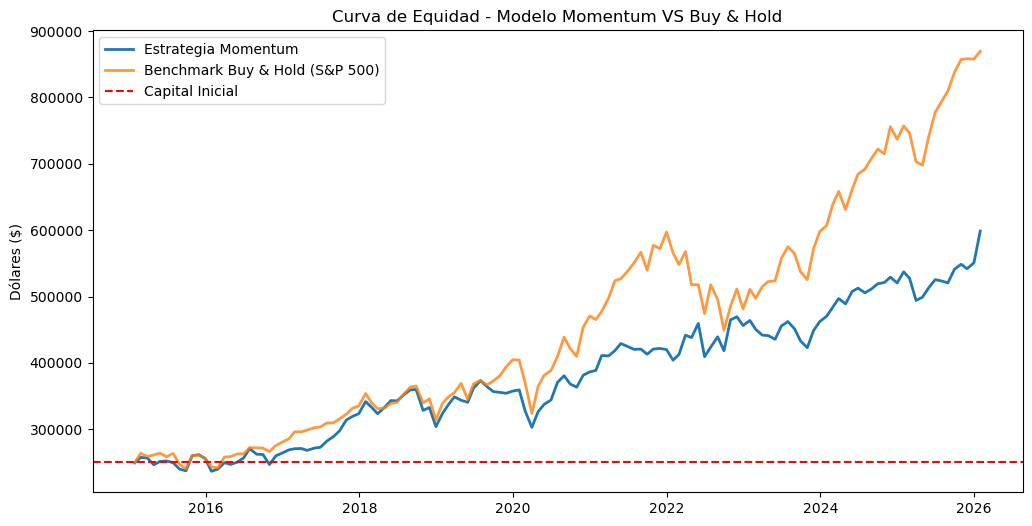

In [38]:
# Simulación de la inversión en SP500
acciones_mercado = capital/precios_sp500_mensual.iloc[0]
inversion_mercado = acciones_mercado*precios_sp500_mensual

#Evolución de la rentabilidad mensual acumulada
plt.figure(figsize=(12,6))

# Graficamos ambas series
plt.plot(precios_momentum_mensual, label='Estrategia Momentum', linewidth=2, color='#1f77b4')
plt.plot(inversion_mercado, label='Benchmark Buy & Hold (S&P 500)', linewidth=2, color='#ff7f0e', alpha=0.8)

# Graficamos que hubiera pasado si no se invirtiese el capital
plt.axhline(y=250000, color='r', linestyle='--', label='Capital Inicial')

plt.title('Curva de Equidad - Modelo Momentum VS Buy & Hold')
plt.ylabel('Dólares ($)')
plt.legend()
plt.show()

Los drawdowns (mayores caídas desde máximos) muestran que a lo largo del periodo es arriesgada la estrategia momentum. Sin embargo, durante la crisis de 2022 las caidas del mercado han sido muy superiores. Tan grande es la diferencia, que por ello, la estrategia Buy & Hold acaba siendo más arriesgada.

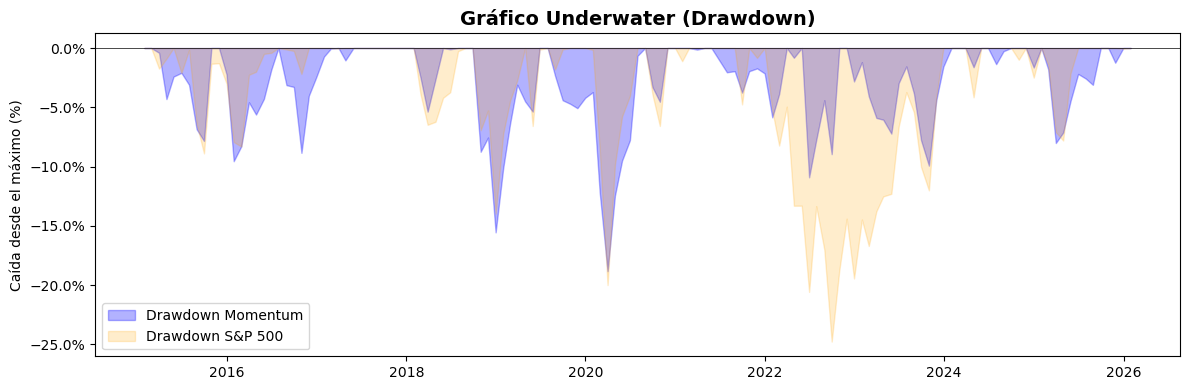

In [39]:
# Calculamos las series de Drawdown (basadas en tus retornos logarítmicos)
def get_drawdown_series(precios):
    # Ya que usas log returns, el wealth acumulado es:
    # Si 'precios' ya es la serie de valor acumulado (como equity_curve):
    rolling_max = precios.cummax()
    drawdown = (precios - rolling_max) / rolling_max
    return drawdown

# Aseguramos que los datos sean 1D usando .values.flatten()
# Esto elimina cualquier estructura de DataFrame o nombres de columnas
dd_momentum = get_drawdown_series(precios_momentum_mensual)
dd_spy = get_drawdown_series(inversion_mercado)

x_axis = dd_momentum.index
y_momentum = dd_momentum.values.flatten()
y_spy = dd_spy.values.flatten()

plt.figure(figsize=(12, 4))

# Graficamos usando los vectores limpios
plt.fill_between(x_axis, y_momentum, 0, color='blue', alpha=0.3, label='Drawdown Momentum')
plt.fill_between(x_axis, y_spy, 0, color='orange', alpha=0.2, label='Drawdown S&P 500')

plt.title('Gráfico Underwater (Drawdown)', fontsize=14, fontweight='bold')
plt.ylabel('Caída desde el máximo (%)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Formatear el eje Y como porcentaje
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend()
plt.tight_layout()
plt.show()

La comparativa de los histogramas de los retornos de ambas estrategias muestran que la distribución de la estrategia Buy & Hold está más desplazada hacia la derecha. Por lo tanto, es una buena confirmación de que **el mercado tiene un mejor rendimiento que la estrategia momentum**.

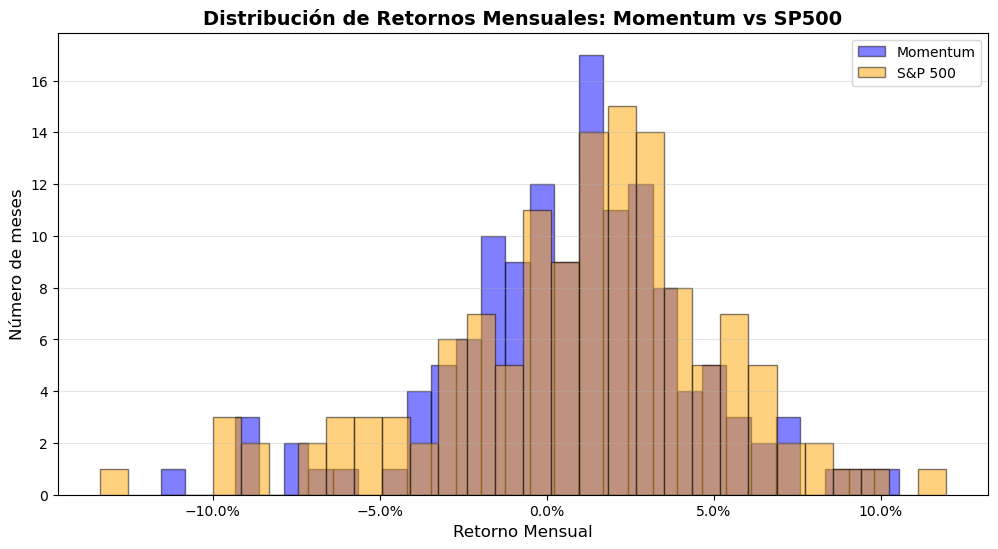

In [40]:
# Histograma de retornos mensuales
# 1. Calculamos los retornos (puedes usar pct_change o tu función get_returns)
ret_estrategia = get_returns(precios_momentum_mensual)
ret_mercado = get_returns(precios_sp500_mensual)

# 2. Configuramos el gráfico
plt.figure(figsize=(12, 6))

# Histograma de la Estrategia
plt.hist(ret_estrategia, bins=30, alpha=0.5, label='Momentum', color='blue', edgecolor='black')

# Histograma del Mercado
plt.hist(ret_mercado, bins=30, alpha=0.5, label='S&P 500', color='orange', edgecolor='black')

# 3. Formato profesional
plt.title('Distribución de Retornos Mensuales: Momentum vs SP500', fontsize=14, fontweight='bold')
plt.xlabel('Retorno Mensual', fontsize=12)
plt.ylabel('Número de meses', fontsize=12)

# Formatear el eje X como porcentaje para que se lea mejor (ej: 5% en lugar de 0.05)
import matplotlib.ticker as mtick
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

De acuerdo con las métricas **Kurtosis** y **Skewness** tenemos:
- **Las colas del mercado** (Skewness) **son más extremas que la estrategia momentum**. Confirmando, una vez más, que la estrategia buy & Hold ha sido más arriesgada.
- Los **eventos anómalos** (Kurtosis) **son más habituales en la estrategia Buy & Hold**.

In [41]:
# Comparativa de métricas de distribuciones entre las dos estrategias (Kurtosis y Skewness)
skew_est = ret_estrategia.skew()
kurt_est = ret_estrategia.kurt()
print('Métricas de distribuciones de la estrategia')
print(f"\tAsimetría (Skewness): {skew_est:.2f}")
print(f"\tCurtosis Excesiva: {kurt_est:.2f}")

skew_mkt = ret_mercado.skew()
kurt_mkt = ret_mercado.kurt()
print()
print('Métricas de distribuciones del mercado')
print(f"\tAsimetría (Skewness): {skew_mkt[0]:.2f}")
print(f"\tCurtosis Excesiva: {kurt_mkt[0]:.2f}")

Métricas de distribuciones de la estrategia
	Asimetría (Skewness): -0.49
	Curtosis Excesiva: 1.25

Métricas de distribuciones del mercado
	Asimetría (Skewness): -0.58
	Curtosis Excesiva: 0.81


C:\Users\mateo\AppData\Local\Temp\ipykernel_2064\1179736292.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\tAsimetría (Skewness): {skew_mkt[0]:.2f}")
C:\Users\mateo\AppData\Local\Temp\ipykernel_2064\1179736292.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\tCurtosis Excesiva: {kurt_mkt[0]:.2f}")


Gráfico que muestra las rentabilidades acumuladas trimestrales de las dos estrategias. Se aprecia cierta correlación pero queda claro que **la estrategia momentum ha sido peor**.

C:\Users\mateo\AppData\Local\Temp\ipykernel_2064\1446396331.py:4: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  momentum_trimestral = precios_momentum_mensual.resample('Q').last().iloc[:-1]
C:\Users\mateo\AppData\Local\Temp\ipykernel_2064\1446396331.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  mercado_trimestral = inversion_mercado.resample('Q').last().iloc[:-1]


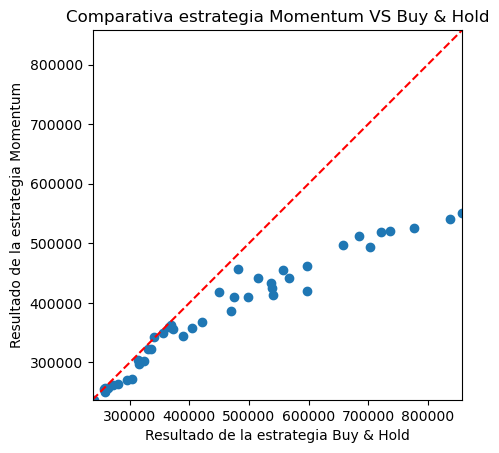

In [42]:
# Análisis de recurrencia de los retornos trimestrales
# Obtenemos los datos trimestrales con la combinación resample('Q').last()
# No seleccinamos la última fecha porque serían datos futuros que no conocemos
momentum_trimestral = precios_momentum_mensual.resample('Q').last().iloc[:-1]
mercado_trimestral = inversion_mercado.resample('Q').last().iloc[:-1]

plt.figure()
plt.scatter(mercado_trimestral, momentum_trimestral)

x = mercado_trimestral.values.flatten()
y = momentum_trimestral.values.flatten()

min_val = np.minimum(x.min(), y.min())
max_val = np.maximum(x.max(), y.max())

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Línea de igualdad
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color = 'red')

plt.title("Comparativa estrategia Momentum VS Buy & Hold")
plt.ylabel("Resultado de la estrategia Momentum")
plt.xlabel("Resultado de la estrategia Buy & Hold")

plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [43]:
porc_momentum_trimestre = np.round((momentum_trimestral.values.flatten() > mercado_trimestral.values.flatten()).sum()*100/len(mercado_trimestral),2)
porc_mercado_trimestre = np.round((mercado_trimestral.values.flatten() > momentum_trimestral.values.flatten()).sum()*100/len(mercado_trimestral),2)
                
print(f"La estrategia momentum es superior al mercado el {porc_momentum_trimestre}% de los trimestres")
print(f"El mercado es superior a la estrategia momentum el {porc_mercado_trimestre}% de los trimestres")

La estrategia momentum es superior al mercado el 2.27% de los trimestres
El mercado es superior a la estrategia momentum el 97.73% de los trimestres


Gráfico que muestra las rentabilidades acumuladas anuales de las dos estrategias. Se aprecia cierta correlación pero queda claro que **la estrategia momentum ha sido peor**.

C:\Users\mateo\AppData\Local\Temp\ipykernel_2064\3462101960.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  momentum_anual = precios_momentum_mensual.resample('Y').last().iloc[:-1]
C:\Users\mateo\AppData\Local\Temp\ipykernel_2064\3462101960.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  mercado_anual = inversion_mercado.resample('Y').last().iloc[:-1]


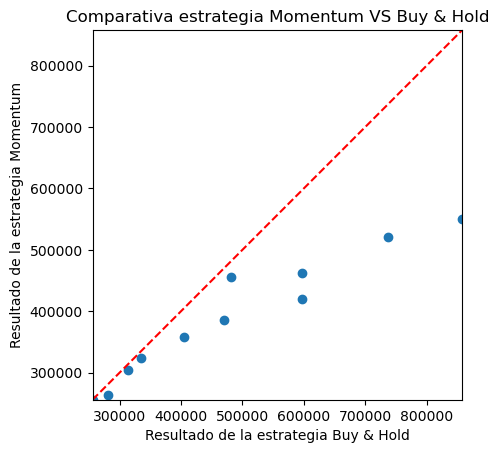

In [44]:
# Análisis de recurrencia de los retornos anuales
# Obtenemos los datos anuales con la combinación resample('Y').last()
# No seleccinamos la última fecha porque serían datos futuros que no conocemos
momentum_anual = precios_momentum_mensual.resample('Y').last().iloc[:-1]
mercado_anual = inversion_mercado.resample('Y').last().iloc[:-1]

plt.figure()

plt.scatter(mercado_anual, momentum_anual)

x = mercado_anual.values.flatten()
y = momentum_anual.values.flatten()

min_val = np.minimum(x.min(), y.min())
max_val = np.maximum(x.max(), y.max())

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Línea de igualdad
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color = 'red')

plt.title("Comparativa estrategia Momentum VS Buy & Hold")
plt.ylabel("Resultado de la estrategia Momentum")
plt.xlabel("Resultado de la estrategia Buy & Hold")

plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [45]:
porc_momentum_anual = np.round((momentum_anual.values.flatten() > mercado_anual.values.flatten()).sum()*100/len(mercado_anual),2)
porc_mercado_anual = np.round((mercado_anual.values.flatten() > momentum_anual.values.flatten()).sum()*100/len(mercado_anual),2)
                
print(f"La estrategia momentum es superior al mercado el {porc_momentum_anual}% de los años")
print(f"El mercado es superior a la estrategia momentum el {porc_mercado_anual}% de los años")

La estrategia momentum es superior al mercado el 0.0% de los años
El mercado es superior a la estrategia momentum el 100.0% de los años


### 5.3. Resumen de resultados

#### 5.3.1. ¿Cómo nos está afectando el sesgo de supervivencia?

El **sesgo de supervivencia** se mitiga porque estamos seleccionando en cada fecha de rebalanceo activos que se encuentren actualmente en el S&P 500 (**universo dinámico**) y, que lo hayan estado en los últimos 13 meses. Si no se hubiera aplicado este filtrado, podríamos haber seleccionado para invertir acciones que no cotizasen (**delisting**) o no estuvieran en el S&P 500 en el periodo de rebalanceo.

#### 5.3.2. ¿Cómo hemos garantizado que no tengamos un problema de look-ahead?

El **look-ahead bias** implica usar datos del futuro que distorsionen el comportamiento del modelo. Está relacionado con otros problemas como el sobreajuste (overfitting). En este caso, mitigamos el look-ahead bias al **calcular los momentum usando los datos desde el mes $t-1$ hasta el $t-r-1$** y al **seleccionar los precios sobre los que se realiza la compraventa de acciones en el rebalanceo**.

Gracias a ello, los rebalanceos se realizan utilizando exclusivamente datos pasados. Las operaciones de rebalanceo se ejecutan el último día hábil bursátil de cada mes.

#### 5.3.3. ¿Crees que existe un problema de overfitting?

**No**, porque no se han optimizado parámetros como el número de meses a tener en cuenta para calcular los momentum. Además, se ha hecho frente al sesgo por supervivencia y el look-ahead bias.

#### 5.3.4. ¿Hemos realizado un rebalanceo irrealista?

**No**, porque los rebalanceos de realizan mensualmente. Si los hicieramos en un periodo inferior el coste de las comisiones sería aún mayor. 

Además, en cada rebalanceo se hace un **filtrado de los activos en los que se puede invertir de acuerdo con las condiciones de presencia en el S&P 500** durante al menos 13 meses.

También, se venden las **acciones de los activos de la cartera que dejen de cotizar o dejen de estar incluidos en el S&P 500**.

Por útlimo, se usan los **precios de apertura (venta) y cierre (compra)** para completar las operaciones de rebalanceo y se simulan las operaciones con un capital considerable. De otro modo, el efecto negativo de las comisiones sería aún mayor.

#### 5.3.5. ¿Cuánto dinero hemos pagado en comisiones de compraventa?

Las comisiones pagadas en cada periodo se almacenan en la variable `comisiones_series`. Las comisiones totales pagadas ascienden a $99.111,16$ $

In [46]:
np.round(comisiones_series.sum(),2)

np.float64(99111.16)

## Notebook 6: Test de Monte Carlo (Monos)

Para configurar el simulador de Monte Carlo, es necesario que fijemos de antemano las variables:

- **`mascara`**: Mascara booleana que determina para cada activo las fechas en las que se puede invertir
- **`matriz_retornos_netos`**: Retornos mensuales porcentuales de cada activo

In [ ]:
#####################  OBTENEMOS LA MÁSCARA PARA SABER EN QUE MESES Y ACTIVOS SE PUEDE INVERTIR (ES FIJA)

matriz_activos = activos_aptos.loc[fechas_reales].fillna(False)
matriz_activos = matriz_activos[precios_compra.columns].values
mascara = matriz_activos*matriz_sp500.loc[fechas_reales].fillna(False)[precios_compra.columns].values.astype(bool)

In [ ]:
###############################   CALCULAMOS LA MATRIZ DE RETORNOS (ES FIJA)

precios_c = precios_compra.values
precios_v = precios_venta.shift(-1).values # El shift se hace una sola vez aquí
com = 0.0023

matriz_retornos_netos = (precios_v * (1 - com)) / (precios_c * (1 + com)) - 1
matriz_retornos_netos = np.nan_to_num(matriz_retornos_netos) # Limpiamos NaNs

Definimos la clase **`SimuladorMonos`** cuyo constructor necesita de las variables **`mascara`** y **`matriz_retornos_netos`** definidas anteriormente, así como el número de simulaciones a realizar y la cantidad a invertir por activo.

La función **`run()`** es la encargada de realizar las simulaciones. **Se realiza de forma vectorizada por lotes**. Mi ordenador no tiene la suficiente capacidad como para hacer el cálculo vectorial completo en una sola operación.

La **salida son los rentabilidades finales de cada una de las simulaciones**. No he podido guardar las rentabilidades mensuales de cada simulación porque no tenía la suficiente memoria.

In [ ]:
class SimuladorMonos:
    def __init__(self, matriz_retornos, mascara, k=20, capital_por_activo=12500):
        """
        Inicializa el simulador con los datos y parámetros base.
        """
        self.matriz_retornos = matriz_retornos
        self.mascara = mascara
        self.k = k
        self.capital_por_activo = capital_por_activo
        
        self.n_meses, self.n_activos = mascara.shape
        
        # Pre-procesamiento: Identificar qué activos son aptos cada mes
        self.activos_aptos_por_mes = [np.where(self.mascara[m])[0] for m in range(self.n_meses)]
        
        # Espacio para resultados
        self.ganancias_netas = None

    def run(self, n_total_simulaciones=25000000, chunk_size=200000):
        """
        Ejecuta la simulación masiva utilizando procesamiento por bloques (chunks).
        """
        self.ganancias_netas = np.zeros(n_total_simulaciones)
        
        print(f"Iniciando cálculo masivo...")
        start_time = time.time()

        for i in range(0, n_total_simulaciones, chunk_size):
            n_sim = min(chunk_size, n_total_simulaciones - i)
            ganancia_bloque = np.zeros(n_sim)
            
            # Bucle por mes (vectorizado para todas las sims del chunk)
            for m in range(self.n_meses):
                aptos = self.activos_aptos_por_mes[m]
                n_aptos = len(aptos)
                
                if n_aptos >= self.k:
                    # 1. Generar aleatorios para selección
                    rand_mes = np.random.random((n_sim, n_aptos))
                    
                    # 2. Selección de los k mejores índices (aleatorios)
                    idx_relativo = np.argpartition(rand_mes, -self.k, axis=1)[:, -self.k:]
                    
                    # 3. Obtener retornos reales
                    retornos_aptos = self.matriz_retornos[m, aptos]
                    retornos_elegidos = np.take_along_axis(retornos_aptos[None, :], idx_relativo, axis=1)
                    
                    # 4. Acumular ganancia monetaria
                    ganancia_bloque += retornos_elegidos.sum(axis=1) * self.capital_por_activo
            
            # Guardar bloque en el array principal
            self.ganancias_netas[i:i+n_sim] = ganancia_bloque
            
            # Feedback de progreso
            if i % 1000000 == 0:
                print('Simulación '+str(i))
        end_time = time.time()
        total_time = end_time - start_time
        print(f"Completado en {total_time/3600:.2f} horas")
        return self.ganancias_netas

Al llamar a la clase **`SimuladorMonos`** se ejecuta la función **`run()`** con los datos. En este caso, ha tardado en realizar todas las simulaciones unas **10 horas y media**. Por lo que cumple con la condición de ejecución en menos de 24 horas.

En la variable **`ganancias_netas_monos`** se almacena el excedente del capital inicial (rentabilidad) de cada una de las simulaciones. La salida en este caso, es un array de 25.000.000 posiciones.

In [56]:
# 1. Instanciar (puedes cambiar k o el capital aquí)
simulador = SimuladorMonos(matriz_retornos_netos, mascara, k=20, capital_por_activo=12500)

# 2. Ejecutar la simulación
ganancias_netas_monos = simulador.run(n_total_simulaciones=25000000, chunk_size=200000)

Iniciando cálculo masivo...
Simulación 0
Simulación 1000000
Simulación 2000000
Simulación 3000000
Simulación 4000000
Simulación 5000000
Simulación 6000000
Simulación 7000000
Simulación 8000000
Simulación 9000000
Simulación 10000000
Simulación 11000000
Simulación 12000000
Simulación 13000000
Simulación 14000000
Simulación 15000000
Simulación 16000000
Simulación 17000000
Simulación 18000000
Simulación 19000000
Simulación 20000000
Simulación 21000000
Simulación 22000000
Simulación 23000000
Simulación 24000000
Completado en 10.59 horas


Cargamos el resultado de la estrategia momentum que hemos obtenido para poder compararlo con los resultados de las simulaciones.

In [87]:
# Carga la curva de la estrategia
equity_estrategia = pd.read_csv('equity_estrategia.csv', index_col=0, parse_dates=True)

# Asegúrate de extraer los valores correctamente para el gráfico
valores_estrategia = equity_estrategia.iloc[:, 0] # Primera columna

Aquí calculamos el capital final de cada una de las simulaciones. Es decir, a cada uno de los excedentes obtenidos por las simulaciones, se le suma el capital inicial de $250.000$. Estos valores serán los que compararemos con el resultado de la estrategia.

In [88]:
# Obtenemos los valores finales para monos y momentum
capital_final_monos = 250000 + ganancias_netas_monos
capital_final_momentum = valores_estrategia.iloc[-1]

A partir de aquí se mostrarán gráficos y tablas que muestren los resultados de las simulaciones versus la estrategia momentum.

La primera muestra el **percentil de nuestra estrategia** comparado con los resultados finales de las 25.000.000 simulaciones. El resultado de la estrategia tiene un percentil muy elevado. Por lo que podría hacernos pensar que haya habido cierto sobreajuste o que las **penalizaciones por comisiones afectan mucho más** que en el caso de la estrategia momentum.

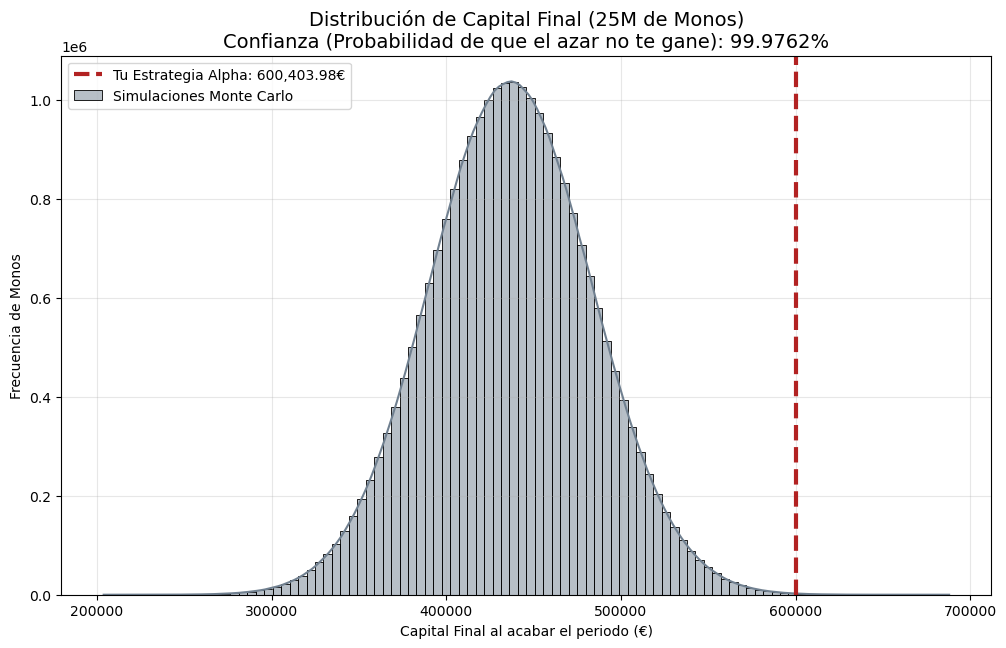

In [77]:
plt.figure(figsize=(12, 7))
sns.histplot(capital_final_monos, bins=100, kde=True, color='slategray', label='Simulaciones Monte Carlo')
plt.axvline(capital_final_momentum, color='firebrick', linestyle='--', linewidth=3, 
            label=f'Tu Estrategia Alpha: {capital_final_momentum:,.2f}€')

# Cálculo del p-value (Filtro de confianza)
p_value = np.mean(capital_final_monos > capital_final_momentum)

plt.title(f'Distribución de Capital Final (25M de Monos)\nConfianza (Probabilidad de que el azar no te gane): {(1-p_value)*100:.4f}%', fontsize=14)
plt.xlabel('Capital Final al acabar el periodo (€)')
plt.ylabel('Frecuencia de Monos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

A continuación, se ejecuta una breve simulación de 200.000 monos para poder tener una muestra con la que comparar los resultados mensuales de la estrategia.

In [78]:
# EJECUTAR ESTO PARA OBTENER LA MUESTRA DEL GRÁFICO
n_monos_grafico = 200000
n_meses = mascara.shape[0]

# Matriz para guardar el retorno de cada mes de cada mono de la muestra
retornos_mensuales_muestra = np.zeros((n_monos_grafico, n_meses))

for m in range(n_meses):
    aptos = activos_aptos_por_mes[m]
    if len(aptos) >= k:
        rand_mes = np.random.random((n_monos_grafico, len(aptos)))
        idx_relativo = np.argpartition(rand_mes, -k, axis=1)[:, -k:]
        retornos_aptos = matriz_retornos_netos[m, aptos]
        
        # Guardamos la SUMA de los retornos de los k activos elegidos para ese mes
        # Esto es el % que gana el mono ese mes concreto
        retornos_mensuales_muestra[:, m] = np.take_along_axis(retornos_aptos[None, :], idx_relativo, axis=1).sum(axis=1)

El segundo gráfico muestra la **rentabilidad acumulada** de la estrategia momentum con respecto a las obtenidas por estas 200.000 simulaciones. Tal y como se puede apreciar, **la rentabilidad acumulada de la estrategia (marcada en rojo) es muy elevada**.

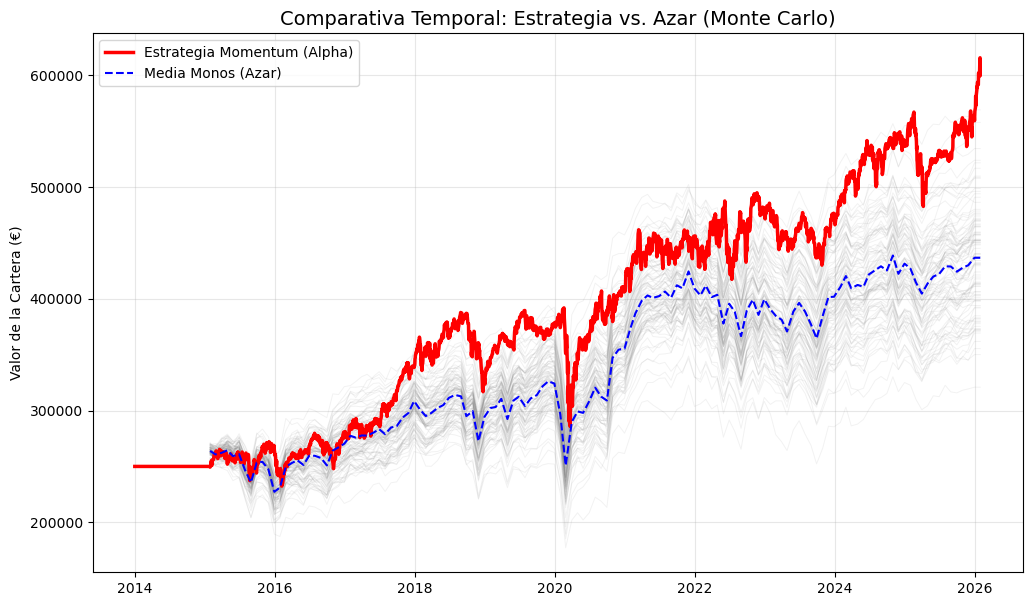

In [89]:
# Calcular las curvas de los monos de la muestra
# retornos_mensuales_muestra tiene forma (1000, 133)
curvas_monos = 250000 + (retornos_mensuales_muestra * 12500).cumsum(axis=1)

# Visualización Profesional
plt.figure(figsize=(12, 7))

# Graficar la nube de incertidumbre (Monos)
fechas_grafico = fechas_reales # Ajusta si falta alguna fecha de inicio
for i in range(100): # Solo 100 líneas para no saturar
    plt.plot(fechas_grafico, curvas_monos[i, :], color='gray', alpha=0.1, linewidth=0.7)

# Graficar tu estrategia
plt.plot(equity_estrategia.index, equity_estrategia.values, 
         color='red', linewidth=2.5, label='Estrategia Momentum (Alpha)')

# Graficar la media de los monos
plt.plot(fechas_grafico, curvas_monos.mean(axis=0), 
         color='blue', linestyle='--', label='Media Monos (Azar)')

plt.title('Comparativa Temporal: Estrategia vs. Azar (Monte Carlo)', fontsize=14)
plt.ylabel('Valor de la Cartera (€)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

A continuación, se calculan métricas de evaluación que nos permitan comparar el resultado de la estrategia comparado con el resultado de las 200.000 simulaciones. Las conclusiones son las siguientes:

- La **rentabilidad esperada es mucho mayor en el caso de la estrategia momentum**.
- La **estrategia momentum tiene un mayor riesgo por máximo drawdown que el promedio y mediana de las simulaciones**.

In [94]:
# --- Cálculo de métricas para la Estrategia ---
retornos_estrategia = equity_estrategia.pct_change().dropna()
# Retorno Anualizado (asumiendo rebalanceo mensual -> 12 meses)
retorno_anual_est = (1 + (equity_estrategia.iloc[-1] / 250000 - 1)) ** (12 / len(fechas_reales)) - 1

# Max Drawdown Estrategia
rolling_max = equity_estrategia.cummax()
drawdowns = (equity_estrategia - rolling_max) / rolling_max
max_dd_est = drawdowns.min()

# --- Cálculo de métricas para los 1.000 Monos ---
# Retorno Anualizado Monos
retorno_total_monos = curvas_monos[:, -1] / 250000 - 1
retorno_anual_monos = (1 + retorno_total_monos) ** (12 / len(fechas_reales)) - 1

# Max Drawdown Monos (vectorizado)
# curvas_monos tiene forma (1000, 133)
rolling_max_monos = np.maximum.accumulate(curvas_monos, axis=1)
drawdowns_monos = (curvas_monos - rolling_max_monos) / rolling_max_monos
max_dd_monos = drawdowns_monos.min(axis=1)

val_max_dd_est = max_dd_est.iloc[0] if isinstance(max_dd_est, pd.Series) else max_dd_est
val_retorno_anual_est = retorno_anual_est.iloc[0] if isinstance(retorno_anual_est, pd.Series) else retorno_anual_est

In [105]:
# --- Aseguramos valores escalares (floats) para los gráficos ---
val_max_dd_est = float(max_dd_est.iloc[0]) if hasattr(max_dd_est, 'iloc') else float(max_dd_est)
val_retorno_anual_est = float(retorno_anual_est.iloc[0]) if hasattr(retorno_anual_est, 'iloc') else float(retorno_anual_est)

# --- Crear Tabla de Métricas ---
df_comparativo = pd.DataFrame({
    'Métrica': ['Retorno Anualizado', 'Máximo Drawdown', 'Capital Final'],
    'Estrategia Momentum': [
        f"{val_retorno_anual_est:.2%}", 
        f"{val_max_dd_est:.2%}", 
        f"{float(equity_estrategia.iloc[-1]):,.2f} €"
    ],
    'Media Monos (Azar)': [
        f"{retorno_anual_monos.mean():.2%}", 
        f"{max_dd_monos.mean():.2%}", 
        f"{curvas_monos[:, -1].mean():,.2f} €"
    ],
    'Mediana Monos (Azar)': [
        f"{np.median(retorno_anual_monos):.2%}", 
        f"{np.median(max_dd_monos):.2%}", 
        f"{np.median(curvas_monos[:, -1]):,.2f} €"
    ]
})

display(df_comparativo) # O print(df_comparativo)

C:\Users\mateo\AppData\Local\Temp\ipykernel_8564\3237426959.py:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  f"{float(equity_estrategia.iloc[-1]):,.2f} €"


,Métrica,Estrategia Momentum,Media Monos (Azar),Mediana Monos (Azar)
0,Retorno Anualizado,8.23%,5.11%,5.16%
1,Máximo Drawdown,-27.11%,-24.22%,-23.80%
2,Capital Final,"600,403.98 €","436,744.37 €","436,694.11 €"


En el siguiente gráfico se muestra un histograma con los máximos drawdowns de las simulaciones. En rojo se marca el máximo drawdown de la estrategia momentum.

Se aprecia que dada la rentabilidad obtenida con respecto a los monos, el **riesgo asociado a nuestra estrategia no es tan elevado**. La rentabilidad se encuentra por encima del percentil 99 y el máximo drawdown se encuentra mucho más cercano a la mediana.

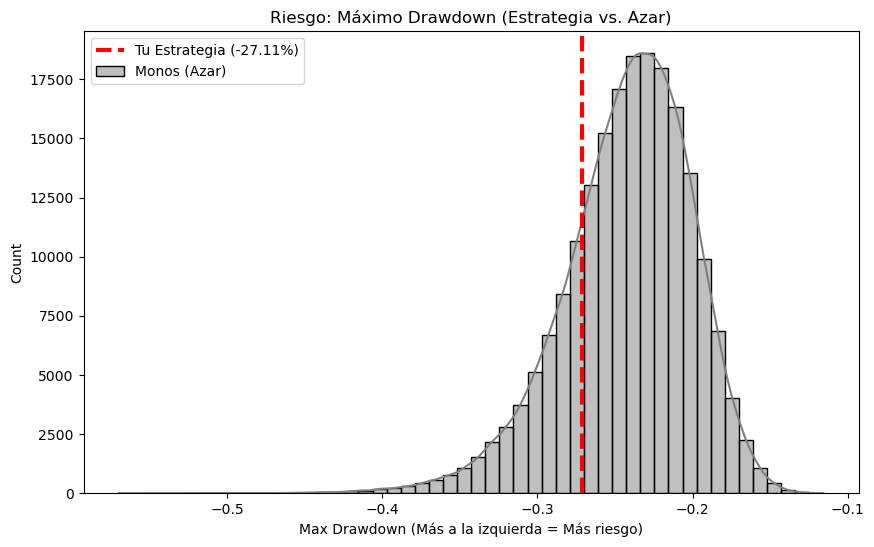

In [111]:
plt.figure(figsize=(10, 6))
sns.histplot(max_dd_monos, bins=50, color='gray', kde=True, label='Monos (Azar)')
plt.axvline(val_max_dd_est, color='red', linestyle='--', linewidth=3, label=f'Tu Estrategia ({val_max_dd_est:.2%})')
plt.title('Riesgo: Máximo Drawdown (Estrategia vs. Azar)')
plt.xlabel('Max Drawdown (Más a la izquierda = Más riesgo)')
plt.legend()
plt.show()

El siguiente boxplot muestra la rentabilidad de las simulaciones comparada con la de la estrategia momentum (marcada en rojo). Se aprecia que **la rentabilidad de la estrategia se encuentra en un percentil muy elevado** (está por encima del bigote superior).

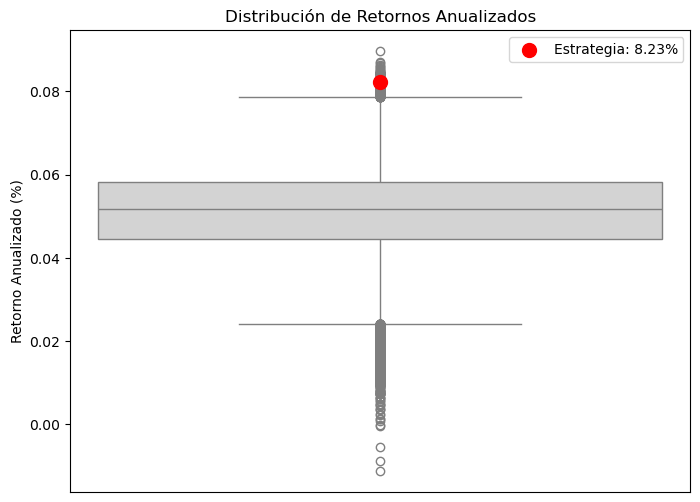

In [112]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=retorno_anual_monos, color='lightgrey', showfliers=True)
plt.scatter(0, val_retorno_anual_est, color='red', s=100, zorder=5, label=f'Estrategia: {val_retorno_anual_est:.2%}')
plt.title('Distribución de Retornos Anualizados')
plt.ylabel('Retorno Anualizado (%)')
plt.xticks([]) 
plt.legend()
plt.show()

El último gráfico muestra la relación rentabilidad versus riesgo (máximo drawdown) de la estrategia (marcada con el punto rojo) comparado con el resultado de las 200.000 simulaciones.
- Se puede ver que para el nivel de la rentabilidad de la estrategia, el máximo drawdown es el menor, indicativo de que **la estrategia tiene un mayor riesgo del esperado**.
- Por otro lado, si fijamos el valor del máximo drawdown se aprecia que la **rentabilidad de la estrategia momentum es mayor que la esperada**.
- En conclusión, el resultado de la **estrategia momentum se encuentra por encima de la frontera eficiente**.

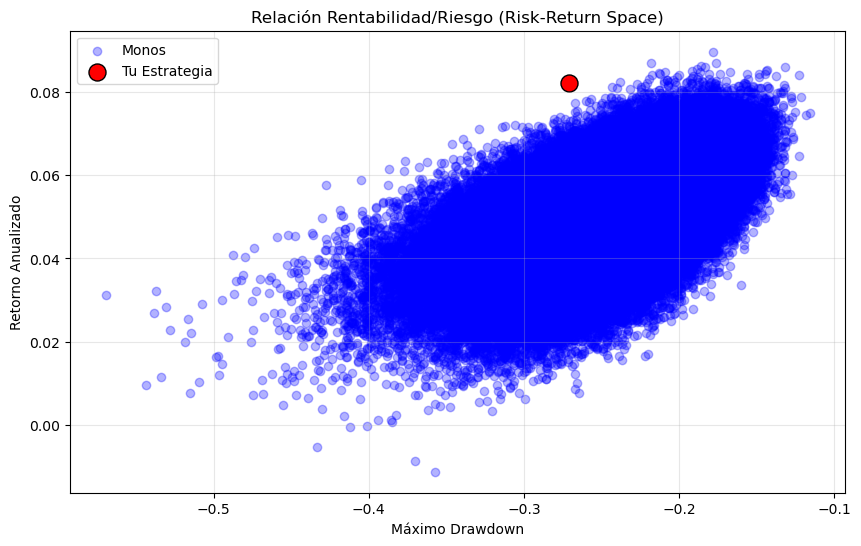

In [104]:
# Supongamos que retorno_benchmark es el retorno total del SPY en el periodo
# Si no lo tienes calculado: retorno_benchmark = 0.10 (ejemplo)

plt.figure(figsize=(10, 6))
plt.scatter(max_dd_monos, retorno_anual_monos, alpha=0.3, color='blue', label='Monos')
plt.scatter(max_dd_est, retorno_anual_est, color='red', s=150, edgecolors='black', label='Tu Estrategia')

plt.title('Relación Rentabilidad/Riesgo (Risk-Return Space)')
plt.ylabel('Retorno Anualizado')
plt.xlabel('Máximo Drawdown')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

En conclusión, **la estrategia momentum es claramente superior a invertir al azar de forma consistente**.